In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yt
yt.set_log_level("error")


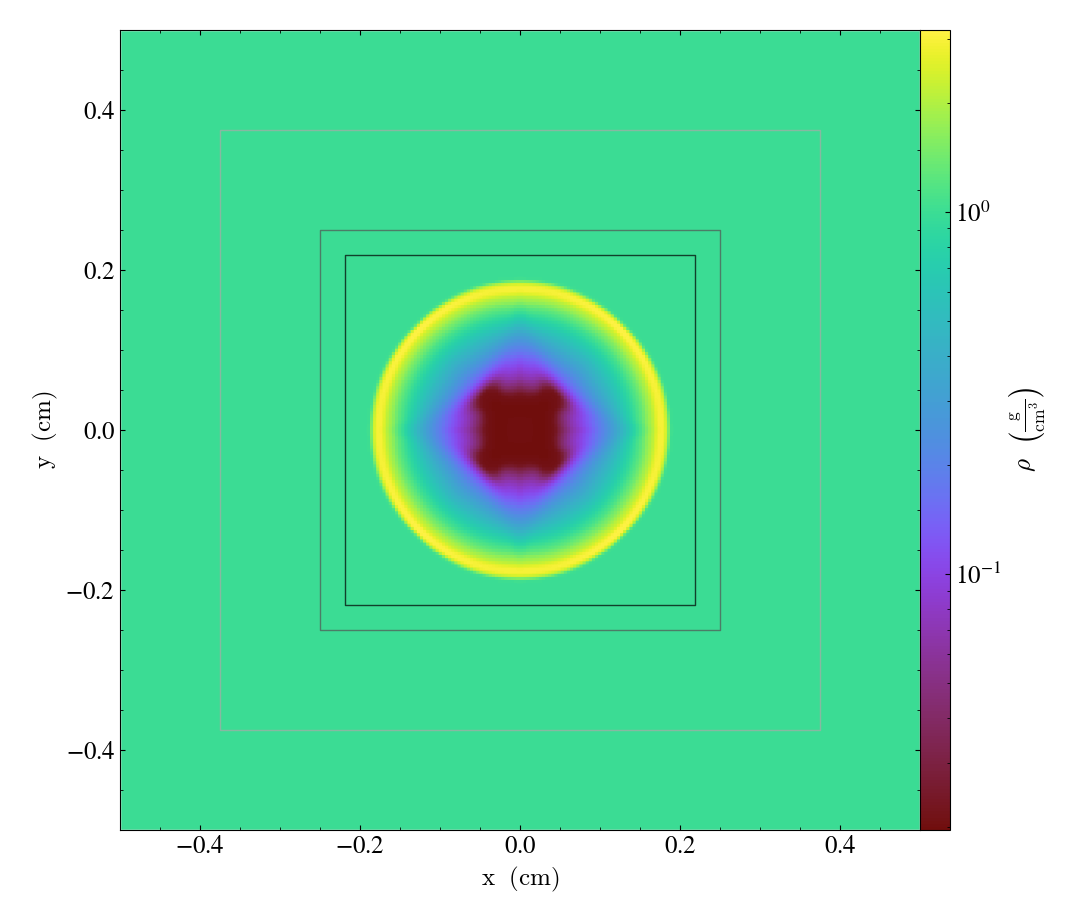

In [33]:
ds = yt.load('../run/sedov_2d_cyl_in_cart_plt00080/', hint="castro")
sl = yt.SlicePlot(ds, 'z', 'density')
sl.annotate_grids()

In [4]:
ds.field_list

[('boxlib', 'Gamma_1'),
 ('boxlib', 'MachNumber'),
 ('boxlib', 'StateErr_0'),
 ('boxlib', 'StateErr_1'),
 ('boxlib', 'StateErr_2'),
 ('boxlib', 'Temp'),
 ('boxlib', 'X(X)'),
 ('boxlib', 'abar'),
 ('boxlib', 'angular_momentum_x'),
 ('boxlib', 'angular_momentum_y'),
 ('boxlib', 'angular_momentum_z'),
 ('boxlib', 'circvel'),
 ('boxlib', 'density'),
 ('boxlib', 'divu'),
 ('boxlib', 'eint_E'),
 ('boxlib', 'eint_e'),
 ('boxlib', 'entropy'),
 ('boxlib', 'kineng'),
 ('boxlib', 'logden'),
 ('boxlib', 'magmom'),
 ('boxlib', 'magvel'),
 ('boxlib', 'magvort'),
 ('boxlib', 'pressure'),
 ('boxlib', 'radvel'),
 ('boxlib', 'rho_E'),
 ('boxlib', 'rho_X'),
 ('boxlib', 'rho_e'),
 ('boxlib', 'soundspeed'),
 ('boxlib', 'x_velocity'),
 ('boxlib', 'xmom'),
 ('boxlib', 'y_velocity'),
 ('boxlib', 'ymom'),
 ('boxlib', 'z_velocity'),
 ('boxlib', 'zmom')]

(0.015625, 0.984375)

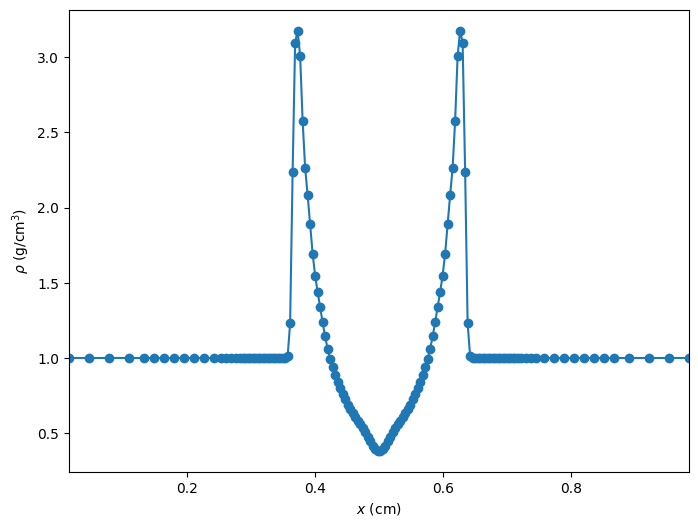

In [28]:
# create a line plot of the density parallel to the x-axis that cuts through the 
# point of maximum density 

_, c = ds.find_max("density") # find the location of the point of maximum density
ax = 0 # take cut parallel to x-axis

# use ortho_ray to cut through c 
ray = ds.ortho_ray(ax, (c[1], c[2]))

# sort values by x so there are no discontinuities in the line plot 
srt = np.argsort(ray['x'])

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ray['x'][srt], ray['density'][srt], '-o')
ax.set_xlabel(r'$x$ (cm)')
ax.set_ylabel(r'$\rho$ (g/cm$^3$)')
ax.set_xlim([ray['x'][srt][0], ray['x'][srt][-1]])